# Artificial Neural Network — From Scratch
### Binary Image Classification : Cat 🐱 vs No-Cat 🚫

---

Our network looks like this:

```
Image pixels  →  Layer 1  →  Layer 2  →  Output
  (input)       3 neurons    2 neurons   1 neuron → ŷ (cat or not?)
```

---
## Step 0 — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

print("Ready!")

Ready!


---
## Step 1 — The Sigmoid Activation Function

The sigmoid function squishes any number into a value between **0 and 1**.
We use it to get a probability — *"how likely is this a cat?"*

$$g(z) = \frac{1}{1 + e^{-z}}$$

Its derivative (needed later for backprop):
$$g'(z) = g(z) \cdot (1 - g(z))$$

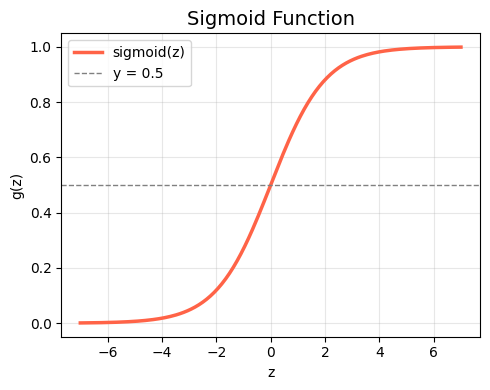

sigmoid(0)  = 0.5
sigmoid(10) = 1.0
sigmoid(-10)= 0.0


In [ ]:
def sigmoid(z):
    # Takes any number z and returns a value between 0 and 1
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    # How fast sigmoid is changing at point z
    s = sigmoid(z)
    return s * (1 - s)


# --- Let's plot it so we can see what it looks like ---
z_values = np.linspace(-7, 7, 200)

plt.figure(figsize=(5, 4))
plt.plot(z_values, sigmoid(z_values), color='tomato', linewidth=2.5, label='sigmoid(z)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
plt.title('Sigmoid Function', fontsize=14)
plt.xlabel('z');  plt.ylabel('g(z)')
plt.legend();     plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quick test
print("sigmoid(0)  =", sigmoid(0))    # should be 0.5
print("sigmoid(10) =", round(sigmoid(10), 4))   # close to 1
print("sigmoid(-10)=", round(sigmoid(-10), 4))  # close to 0

---
## Step 2 — Load a Real Dataset (CIFAR-10: Cat vs. Airplane)

We use the **CIFAR-10** dataset — 60,000 real 32×32 RGB images across 10 classes.

We pick two classes for binary classification:
- **Label 1** = Cat (CIFAR class 3)
- **Label 0** = Airplane (CIFAR class 0)

Each image is flattened: 32 × 32 × 3 = **3072 features** per image.

Data shape convention (same as before): $X \in \mathbb{R}^{n \times m}$ where $n=3072$, $m$ = number of images.

CIFAR-10 is a predefined dataset containing 10 classes. Each class has a fixed numeric label assigned by the dataset creators. In CIFAR-10, airplane corresponds to label 0 and cat corresponds to label 3. We selected only these two classes to convert the original 10-class problem into a binary classification problem.

In [ ]:
!pip install tensorflow -q
from tensorflow.keras.datasets import cifar10

In [ ]:
(X_raw_train, Y_raw_train), (X_raw_test, Y_raw_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


This function loads the CIFAR-10 dataset and returns two tuples:

((X_train, Y_train), (X_test, Y_test))

X_raw_train = train_images

Y_raw_train = train_labels

X_raw_test = test_images

Y_raw_test = test_labels

The dataset already comes pre-split into training and testing sets.

Total images = 60,000

Training set = 50,000 images

Test set     = 10,000 images

In [ ]:
print(X_raw_train.shape)
print(Y_raw_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [ ]:
print(X_raw_test.shape)
print(Y_raw_test.shape)

(10000, 32, 32, 3)
(10000, 1)


In [ ]:
# Load CIFAR-10
# (X_raw_train, Y_raw_train), (X_raw_test, Y_raw_test) = cifar10.load_data()
'''data = cifar10.load_data()

train_data = data[0]
test_data  = data[1]

X_raw_train = train_data[0]
Y_raw_train = train_data[1]

X_raw_test = test_data[0]
Y_raw_test = test_data[1] '''


In [ ]:
print(Y_raw_train[:5])  # 50000 labels,each label is a single number from 0 to 9 ,where each number represents a class:

[[6]
 [9]
 [9]
 [4]
 [1]]


In [ ]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

for i, name in enumerate(class_names):
    print(i, "->", name)

0 -> airplane
1 -> automobile
2 -> bird
3 -> cat
4 -> deer
5 -> dog
6 -> frog
7 -> horse
8 -> ship
9 -> truck


CIFAR-10 already comes with a predefined train-test split (50k/10k). If we want a different split such as 70-30, we first merge all 60,000 samples and then use train_test_split() to create a new split according to our requirement.

In [ ]:
#Step 1: Load CIFAR-10
(X_train_orig, Y_train_orig), (X_test_orig, Y_test_orig) = cifar10.load_data()

In [ ]:
#Step 2: Combine all 60,000 images
import numpy as np

X = np.concatenate((X_train_orig, X_test_orig), axis=0)
Y = np.concatenate((Y_train_orig, Y_test_orig), axis=0)

print(X.shape)  # (60000, 32, 32, 3)
print(Y.shape)  # (60000, 1)

(60000, 32, 32, 3)
(60000, 1)


In [ ]:
# Step 3: Create a 70-30 split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.10,      # 30% test
    random_state=42,
    stratify=Y           # keeps class proportions balanced
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(54000, 32, 32, 3)
(6000, 32, 32, 3)


In [ ]:
(X_raw_train, Y_raw_train), (X_raw_test, Y_raw_test) = cifar10.load_data()

print("X_raw_train: ",X_raw_train.shape)
print("Y_raw_train",Y_raw_train.shape)
print("X_raw_test",X_raw_test.shape)
print("X_raw_test",Y_raw_test.shape)

X_raw_train:  (50000, 32, 32, 3)
Y_raw_train (50000, 1)
X_raw_test (10000, 32, 32, 3)
X_raw_test (10000, 1)


We pick two classes for binary classification:
- **Label 1** = Cat (CIFAR class 3)
- **Label 0** = Airplane (CIFAR class 0)

Each image is flattened: 32 × 32 × 3 = **3072 features** per image.

Data shape convention (same as before): $X \in \mathbb{R}^{n \times m}$ where $n=3072$, $m$ = number of images.

In [ ]:
(X_raw_train, Y_raw_train), (X_raw_test, Y_raw_test) = cifar10.load_data()
CAT      = 3 #CIFAR-10 has 10 classes. CAT = 3 is just the index CIFAR-10 uses to identify cat images internally.
AIRPLANE = 0

# ---- How many images per class ----
N_TRAIN = 500   # N_TRAIN cats + N_TRAIN airplanes = 2*N_TRAIN training images
N_TEST  = 100   # N_TEST cats + N_TEST airplanes = 2*N_TEST test images

def extract_classes(X, Y, cls1, cls2, n_per_class):  # X = images , Y = labels, cls1 = cat ,cls2 = airplane and n_per_class = how many images per class

    idx1 = np.where(Y[:, 0] == cls1)[0][:n_per_class] # Let  Y =[3,4,3,1,0,3,0] Y == 3 , [True,False,True,False,False,True,False] ,
                                                 # np.where() returns positions: [0,2,5]
                                                 # These are cat indices.Take only the first n_per_class indices or cat images are selected.
                                                 # idx1 means Find all cat images and keep only the first (n_per_class = 500)

    idx2 = np.where(Y[:, 0] == cls2)[0][:n_per_class]  #  # idx1 means Find all airplane images and keep only the first (n_per_class = 500)
    idx  = np.concatenate([idx1, idx2])
    np.random.shuffle(idx)
    return X[idx], (Y[idx, 0] == cls1).astype(float)  # Return images X[idx] and binary labels (Y[idx, 0] == cls1) if True  -> Cat else Airplane

X_tr_raw, Y_tr = extract_classes(X_raw_train, Y_raw_train, CAT, AIRPLANE, N_TRAIN)
X_te_raw, Y_te = extract_classes(X_raw_test,  Y_raw_test,  CAT, AIRPLANE, N_TEST)

# Flatten + normalize → shape (3072, m)
X_train = X_tr_raw.reshape(X_tr_raw.shape[0], -1).T / 255.0
X_test  = X_te_raw.reshape(X_te_raw.shape[0], -1).T / 255.0

Y_train = Y_tr.reshape(1, -1)
Y_test  = Y_te.reshape(1, -1)

n = X_train.shape[0]   # Input layer has 3072 neurons
print()
print("Each CIFAR image: becomes a vector of length 3072.")
print("Training set shape:", X_train.shape)
print("Test set shape:    ", X_test.shape)
print("Cats in training:    ", int(Y_train.sum()))
print("Airplanes in training:", int((1 - Y_train).sum()))




Each CIFAR image: becomes a vector of length 3072.
Training set shape: (3072, 1000)
Test set shape:     (3072, 200)
Cats in training:     500
Airplanes in training: 500


We use a subset of CIFAR-10 primarily to reduce computational cost and training time. Since the ANN is implemented from scratch in NumPy for demostration purposes, a smaller balanced dataset allows us to demonstrate data preprocessing, forward propagation, and backpropagation efficiently while still learning meaningful patterns from the images.

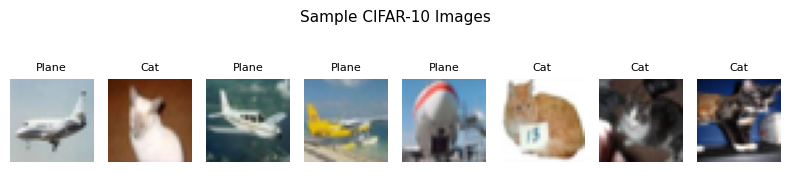

In [ ]:
# Show a few sample images
fig, axes = plt.subplots(1, 8, figsize=(8, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_tr_raw[i])
    ax.set_title('Cat' if Y_train[0, i] == 1 else 'Plane', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 3 — Initialize Weights and Biases

Each layer has:
- **W** (weights) — a matrix of numbers the network will learn
- **b** (bias)    — an extra number added to shift the output

From notes:
- $W^{[1]} \in \mathbb{R}^{3 \times n}$,  $b^{[1]} \in \mathbb{R}^{3 \times 1}$
- $W^{[2]} \in \mathbb{R}^{2 \times 3}$,  $b^{[2]} \in \mathbb{R}^{2 \times 1}$
- $W^{[3]} \in \mathbb{R}^{1 \times 2}$,  $b^{[3]} \in \mathbb{R}^{1 \times 1}$

We start with **small random weights** (not zeros — zeros would make all neurons identical).

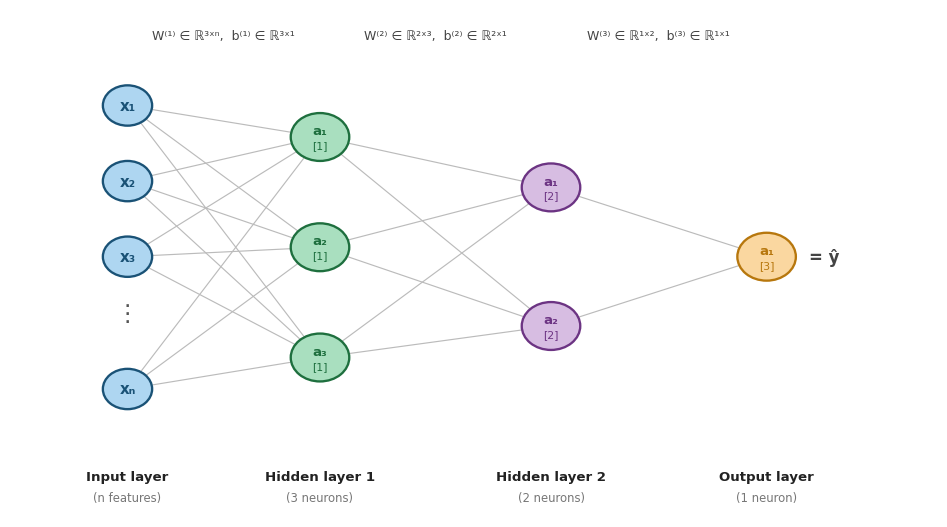

In [ ]:
def initialize_weights(n_input, n_layer1, n_layer2, n_output):
    """
    n_input  : number of features (pixels per image)  For CIFAR-10 after flattening: 32×32×3 = 3072
    n_layer1 : how many neurons are in Hidden Layer 1 ,n_layer1 = 3
    n_layer2 : how many neurons are in Hidden Layer 2, n_layer2 = 2
    n_output : neurons in output layer (Binary classification (cat / not-cat) → 1 neuron, so n_output = 1)
    """

    # Layer 1 weights and bias
    W1 = np.random.randn(n_layer1, n_input)  * 0.01   # shape (3, n),Z = W.X + b , W1[i][j] = weight connecting feature j to neuron i.
    b1 = np.zeros((n_layer1, 1))                       # shape (3, 1)

    # Layer 2 weights and bias
    W2 = np.random.randn(n_layer2, n_layer1) * 0.01   # shape (2, 3)
    b2 = np.zeros((n_layer2, 1))                       # shape (2, 1)

    # Layer 3 (output) weights and bias
    W3 = np.random.randn(n_output, n_layer2) * 0.01   # shape (1, 2)
    b3 = np.zeros((n_output, 1))                       # shape (1, 1)

    # Pack everything into a dictionary for easy access
    params = {
        'W1': W1, 'b1': b1,
        'W2': W2, 'b2': b2,
        'W3': W3, 'b3': b3
    }

    return params


# Create our network parameters
params = initialize_weights(n_input=n, n_layer1=3, n_layer2=2, n_output=1)

print("Weight and Bias shapes:")
print("  W1:", params['W1'].shape, "  b1:", params['b1'].shape)
print("  W2:", params['W2'].shape, "  b2:", params['b2'].shape)
print("  W3:", params['W3'].shape, "  b3:", params['b3'].shape)

Weight and Bias shapes:
  W1: (3, 3072)   b1: (3, 1)
  W2: (2, 3)   b2: (2, 1)
  W3: (1, 2)   b3: (1, 1)


---
## Step 4 — Forward Propagation

This is how the network makes a **prediction**. We pass the input forward through each layer.

For each layer:
1. Compute $z = W \cdot a + b$ &nbsp;&nbsp; ← linear step
2. Compute $a = g(z)$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;← apply activation

Key Equations:
$$a^{[1]} = g(W^{[1]} x + b^{[1]})$$
$$a^{[2]} = g(W^{[2]} a^{[1]} + b^{[2]})$$
$$\hat{y} = a^{[3]} = g(W^{[3]} a^{[2]} + b^{[3]})$$

In [ ]:
def forward_propagation(X, params):
    """
    X      : input data, shape (n, m)
    params : dictionary with W1,b1,W2,b2,W3,b3

    Returns:
        y_hat  : predictions, shape (1, m)  — probability of being a cat
        C  : saves z and a values (we need these for backprop later)
    """

    W1 = params['W1'];  b1 = params['b1']
    W2 = params['W2'];  b2 = params['b2']
    W3 = params['W3'];  b3 = params['b3']

    # ---- Layer 1 ----
    Z1 = W1 @ X  + b1          # @ means matrix multiply  , W1 is (3, 3072), X is (3072, 1)  →  W1 @ X gives (3, 1).
    A1 = sigmoid(Z1)           # apply sigmoid

    # ---- Layer 2 ----
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    # ---- Output Layer ----
    Z3 = W3 @ A2 + b3
    A3 = sigmoid(Z3)           # ŷ : probability between 0 and 1

    # Save everything so we can use it in backpropagation
    C = {
        'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3, 'A3': A3
    }

    y_hat = A3
    return y_hat, C


# Quick test
y_hat_test, _ = forward_propagation(X_train, params)  # X_train = (3072,1000) and Y_train = (1,1000)
print("Output shape:", y_hat_test.shape,  "  (1 prediction per image)")
print("First 5 predictions (before training):", np.round(y_hat_test[0, :5], 3))

Output shape: (1, 1000)   (1 prediction per image)
First 5 predictions (before training): [0.498 0.498 0.498 0.498 0.498]


---
## Step 5 — Loss and Cost Function

We need a way to **measure how wrong** the network's predictions are.

We use **Binary Cross-Entropy**:

$$L(\hat{y}, y) = -\left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$

The **cost** is the average loss over all m examples:

$$J = \frac{1}{m} \sum_{i=1}^{m} L(\hat{y}^{(i)}, y^{(i)})$$

> Lower J = better predictions. Our goal is to **minimize J**.

In [ ]:
def compute_cost(y_hat, Y):
    """
    y_hat : predicted probabilities, shape (1, m)
    Y     : true labels (0 or 1),    shape (1, m)

    Returns: a single number — the cost J
    """
    m = Y.shape[1]   # number of examples

    # We add a tiny number (1e-8) to avoid log(0) which is -infinity
    cost = -(1 / m) * np.sum(
        Y * np.log(y_hat + 1e-8) + (1 - Y) * np.log(1 - y_hat + 1e-8)
    )

    return float(cost)


# Test it
cost_before = compute_cost(y_hat_test, Y_train)
print("Cost before training:", round(cost_before, 4))
print("(Should be around 0.693 = log(2), because the network is just guessing 50/50)")

Cost before training: 0.6932
(Should be around 0.693 = log(2), because the network is just guessing 50/50)


---
## Step 6 — Backpropagation

We work **backwards** from the output, using the **chain rule** to find how much each weight contributed to the error.

---

### Output Layer (Layer 3) — full derivation

Start from the cost:
$$J = -\frac{1}{m} \sum \left[ y \log(a^{[3]}) + (1-y)\log(1 - a^{[3]}) \right]$$

**Step 1 — differentiate $J$ w.r.t. $a^{[3]}$:**
$$\frac{\partial J}{\partial a^{[3]}} = -\frac{y}{a^{[3]}} + \frac{1-y}{1 - a^{[3]}}$$

**Step 2 — differentiate $a^{[3]} = g(z^{[3]})$ w.r.t. $z^{[3]}$:**
$$\frac{\partial a^{[3]}}{\partial z^{[3]}} = g'(z^{[3]}) = a^{[3]}\,(1 - a^{[3]})$$

**Step 3 — chain rule gives $dZ^{[3]}$:**
$$dZ^{[3]} = \frac{\partial J}{\partial a^{[3]}} \cdot \frac{\partial a^{[3]}}{\partial z^{[3]}} = \left(-\frac{y}{a^{[3]}} + \frac{1-y}{1 - a^{[3]}}\right) \cdot a^{[3]}(1 - a^{[3]})$$

Expanding and simplifying:
$$= -y\,(1 - a^{[3]}) + (1 - y)\,a^{[3]} \;=\; a^{[3]} - y$$

$$\boxed{dZ^{[3]} = A^{[3]} - Y}$$

Then (averaging over $m$ examples):
$$dW^{[3]} = \frac{1}{m}\,dZ^{[3]}\,A^{[2]T}, \qquad db^{[3]} = \frac{1}{m}\sum dZ^{[3]}$$

---

### General pattern

For any layer $l$:

$$dZ^{[l]} = W^{[l+1]T} \cdot dZ^{[l+1]} \;\odot\; g'(Z^{[l]})$$

$$\frac{\partial J}{\partial W^{[l]}} = \frac{1}{m}\,dZ^{[l]}\,A^{[l-1]T}, \qquad \frac{\partial J}{\partial b^{[l]}} = \frac{1}{m}\sum dZ^{[l]}$$

In [ ]:
def back_propagation(X, Y, params, C):
    """
    X      : input data,   shape (n, m)
    Y      : true labels,  shape (1, m)
    params : W and b for each layer
    C  : Z and A saved during forward pass

    Returns: grads — dictionary of dW1, db1, dW2, db2, dW3, db3
    """
    m = X.shape[1]   # number of examples

    # Get saved values from forward pass
    A1 = C['A1'];  Z1 = C['Z1']
    A2 = C['A2'];  Z2 = C['Z2']
    A3 = C['A3']   # this is ŷ

    W2 = params['W2']
    W3 = params['W3']

    # ---- Output layer (Layer 3) ----
    # How wrong is the output?  (ŷ - y)
    dZ3 = A3 - Y                                        # shape (1, m)
    dW3 = (1 / m) * dZ3 @ A2.T                         # shape (1, 2)
    db3 = (1 / m) * np.sum(dZ3, axis=1, keepdims=True) # shape (1, 1)

    # ---- Layer 2 ----
    dZ2 = (W3.T @ dZ3) * sigmoid_derivative(Z2)        # shape (2, m)
    dW2 = (1 / m) * dZ2 @ A1.T                         # shape (2, 3)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True) # shape (2, 1)

    # ---- Layer 1 ----
    dZ1 = (W2.T @ dZ2) * sigmoid_derivative(Z1)        # shape (3, m)
    dW1 = (1 / m) * dZ1 @ X.T                          # shape (3, n)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True) # shape (3, 1)

    grads = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }

    return grads


print("Backprop defined!")

Backprop defined!


---
## Step 7 — Update Weights (Gradient Descent)

Now we **nudge** each weight in the direction that reduces the cost:

$$W^{[l]} = W^{[l]} - \alpha \cdot dW^{[l]}$$
$$b^{[l]}  = b^{[l]}  - \alpha \cdot db^{[l]}$$

$\alpha$ (alpha) is the **learning rate** — how big of a step we take each time.

> Too large → overshoots. Too small → learns very slowly.

In [ ]:
def update_weights(params, grads, learning_rate):
    """
    params        : current weights and biases
    grads         : gradients computed by backprop
    learning_rate : alpha (α) — step size

    Returns: updated params
    """

    params['W1'] = params['W1'] - learning_rate * grads['dW1']
    params['b1'] = params['b1'] - learning_rate * grads['db1']

    params['W2'] = params['W2'] - learning_rate * grads['dW2']
    params['b2'] = params['b2'] - learning_rate * grads['db2']

    params['W3'] = params['W3'] - learning_rate * grads['dW3']
    params['b3'] = params['b3'] - learning_rate * grads['db3']

    return params


print("Weight update defined!")

Weight update defined!


---
## Step 8 — Train the Network!

Now we put it all together. Each **iteration** (epoch) does:

```
1. Forward pass   →  get predictions ŷ
2. Compute cost   →  how wrong are we?
3. Backward pass  →  compute gradients
4. Update weights →  improve the network
5. Repeat!
```

In [ ]:
def train_network(X_train, Y_train, learning_rate=0.5, iterations=1000):
    """
    Trains the ANN and returns the learned parameters and cost history.
    """

    n_features = X_train.shape[0]   # number of pixels

    # Start with random small weights
    params = initialize_weights(n_input=n_features,
                                n_layer1=3,
                                n_layer2=2,
                                n_output=1)

    cost_history = []   # we'll save the cost at each step to plot later

    for i in range(iterations):

        # 1. Forward pass — get predictions
        y_hat, C = forward_propagation(X_train, params)

        # 2. Compute cost — how wrong are we?
        cost = compute_cost(y_hat, Y_train)
        cost_history.append(cost)

        # 3. Backward pass — compute gradients
        grads = back_propagation(X_train, Y_train, params, C)

        # 4. Update weights
        params = update_weights(params, grads, learning_rate)

        # Print cost every 100 steps
        if i % 100 == 0:
            print(f"  Step {i:4d}  |  Cost = {cost:.4f}")

    print()
    # cost_history[-1] → last element of the list = cost at the final iteration.
    print(f"Training done! Final cost = {cost_history[-1]:.4f}")
    return params, cost_history


# --- Train! ---
print("Training the network...")
print("-" * 35)
params, cost_history = train_network(X_train, Y_train,
                                     learning_rate=1.5,
                                     iterations=2000)

Training the network...
-----------------------------------
  Step    0  |  Cost = 0.6931
  Step  100  |  Cost = 0.6931
  Step  200  |  Cost = 0.6931
  Step  300  |  Cost = 0.6931
  Step  400  |  Cost = 0.6931
  Step  500  |  Cost = 0.6931
  Step  600  |  Cost = 0.6751
  Step  700  |  Cost = 0.6197
  Step  800  |  Cost = 0.4272
  Step  900  |  Cost = 0.3730
  Step 1000  |  Cost = 0.4006
  Step 1100  |  Cost = 0.3667
  Step 1200  |  Cost = 0.5431
  Step 1300  |  Cost = 0.3710
  Step 1400  |  Cost = 0.3187
  Step 1500  |  Cost = 0.3030
  Step 1600  |  Cost = 0.5379
  Step 1700  |  Cost = 0.2756
  Step 1800  |  Cost = 0.3267
  Step 1900  |  Cost = 0.4459

Training done! Final cost = 0.3761


---
## Step 9 — Plot the Learning Curve

If training is working, the **cost should go down** over time.

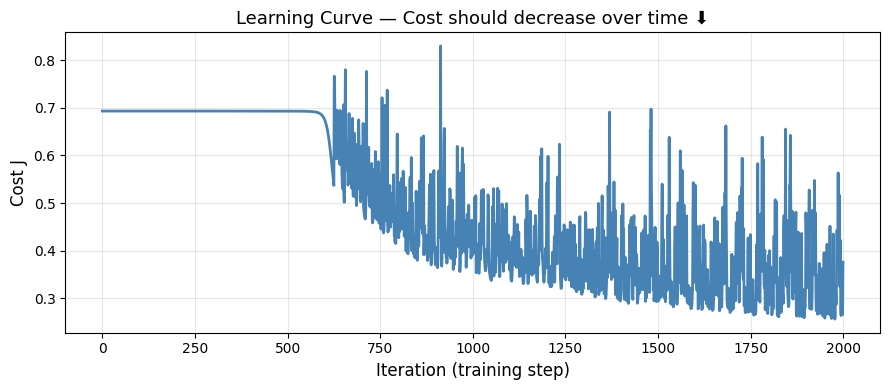

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(cost_history, color='steelblue', linewidth=2)
plt.xlabel('Iteration (training step)', fontsize=12)
plt.ylabel('Cost J', fontsize=12)
plt.title('Learning Curve — Cost should decrease over time ⬇️', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 9b — Visualise the Trained Network

After training, we can **inspect what the network learned** by looking at the weight values on each connection.

### How to read the diagram

| Visual cue | Meaning |
|------------|---------|
| **Red edge** | Positive weight — this input *excites* the neuron |
| **Blue edge** | Negative weight — this input *suppresses* the neuron |
| **Edge intensity / thickness** | Magnitude — stronger weight = bolder line |
| **Node color** | Layer identity (blue=input, green=hidden, yellow=output) |

> **Note on Layer 1 edges:** ^{[1]}$ has shape $ — one weight per pixel per neuron.
> We cannot draw 3072 individual edges, so edge color shows the **mean weight** of each L1 neuron
> averaged over all 3072 input pixels.

The exact weight values are printed on the **L1 → L2** and **L2 → Output** edges,
where there are few enough connections to label clearly.


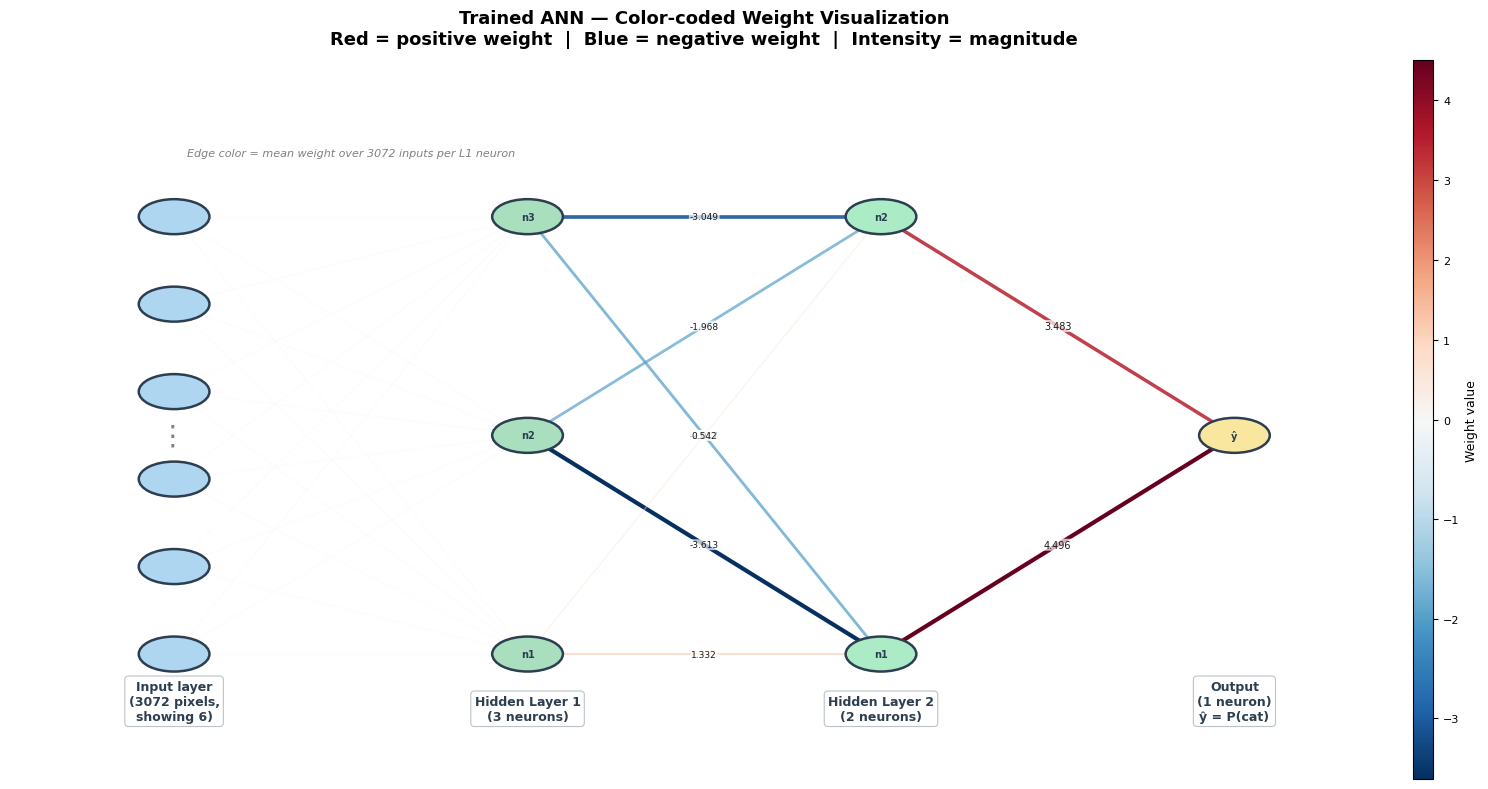

Learned Weights after Training

W1 (L1 neuron mean weights over 3072 inputs):
  Neuron 1: mean(W1[0,:]) = -0.01933
  Neuron 2: mean(W1[1,:]) = -0.02439
  Neuron 3: mean(W1[2,:]) = 0.00180

W2 (Layer1 → Layer2):
[[ 1.33175801 -3.61320516 -2.01680282]
 [ 0.54249193 -1.96771031 -3.04888924]]

W3 (Layer2 → Output):
[[4.49563595 3.48338753]]

b1: [[ 0.05716101 -1.53968224 -2.02763611]]  b2: [[3.50877059 0.88640687]]  b3: [[-4.09360105]]


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

def draw_network(params, n_input_show=6):
    """
    Visualises the trained ANN.
    - Nodes: color-coded by layer
    - Edges: color-coded by weight (red = positive, blue = negative, intensity = magnitude)
    - W1 has 3072 weights per neuron → we display the mean weight per L1 neuron
      broadcast to all shown input nodes (annotated clearly)
    """
    W1 = params['W1']   # (3, 3072)
    W2 = params['W2']   # (2, 3)
    W3 = params['W3']   # (1, 2)

    # For W1: average weight from all 3072 inputs → each L1 neuron
    W1_mean = W1.mean(axis=1)   # shape (3,) — one mean per L1 neuron

    # Build a (3 x n_input_show) matrix using mean values for display
    W1_disp = np.tile(W1_mean[:, None], (1, n_input_show))  # (3, 6)

    # All weights for shared color scale
    all_w = np.concatenate([W1_disp.flatten(), W2.flatten(), W3.flatten()])
    vmin, vmax = all_w.min(), all_w.max()
    # Ensure vcenter=0 is strictly between vmin and vmax
    if vmin >= 0:   vmin = -1e-6
    if vmax <= 0:   vmax =  1e-6
    norm  = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap  = cm.RdBu_r   # red=positive, blue=negative

    layer_sizes  = [n_input_show, 3, 2, 1]
    layer_labels = [
        f'Input layer\n(3072 pixels,\nshowing {n_input_show})',
        'Hidden Layer 1\n(3 neurons)',
        'Hidden Layer 2\n(2 neurons)',
        'Output\n(1 neuron)\nŷ = P(cat)'
    ]
    node_colors = ['#AED6F1', '#A9DFBF', '#ABEBC6', '#F9E79F']

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.1)
    ax.axis('off')

    x_pos = np.linspace(0.08, 0.92, 4)

    # Compute y positions per layer
    def ys(n):
        return list(np.linspace(0.15, 0.85, n)) if n > 1 else [0.5]

    node_ys = [ys(s) for s in layer_sizes]

    # --- Draw edges ---
    def draw_edges(xs, xt, ys_src, ys_dst, W):
        for j, yd in enumerate(ys_dst):
            for i, ys_ in enumerate(ys_src):
                w     = W[j, i]
                color = cmap(norm(w))
                alpha = 0.35 + 0.65 * min(abs(norm(w) - 0.5) * 2, 1.0)
                lw    = 0.8 + 2.2 * min(abs(norm(w) - 0.5) * 2, 1.0)
                ax.plot([xs, xt], [ys_, yd],
                        color=color, lw=lw, alpha=alpha, zorder=1)

    draw_edges(x_pos[0], x_pos[1], node_ys[0], node_ys[1], W1_disp)
    draw_edges(x_pos[1], x_pos[2], node_ys[1], node_ys[2], W2)
    draw_edges(x_pos[2], x_pos[3], node_ys[2], node_ys[3], W3)

    # --- Draw nodes ---
    r = 0.028
    for l in range(4):
        for k, y in enumerate(node_ys[l]):
            circle = plt.Circle((x_pos[l], y), r,
                                 color=node_colors[l], ec='#2C3E50',
                                 lw=1.8, zorder=3)
            ax.add_patch(circle)

            # Label neurons in hidden/output layers with index
            if l > 0:
                ax.text(x_pos[l], y, f'n{k+1}' if l < 3 else 'ŷ',
                        ha='center', va='center', fontsize=7,
                        fontweight='bold', zorder=4, color='#2C3E50')

    # Ellipsis between input nodes to signal truncation
    mid = (node_ys[0][0] + node_ys[0][-1]) / 2
    ax.text(x_pos[0] - 0.001, mid, '⋮', ha='center', va='center',
            fontsize=20, color='gray', zorder=4)

    # --- Layer labels (below) ---
    for l, label in enumerate(layer_labels):
        ax.text(x_pos[l], 0.04, label,
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', color='#2C3E50',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#BDC3C7', lw=0.8))

    # --- Weight annotations on L2→L3 and L3→Output edges (few weights, readable) ---
    for j, yd in enumerate(node_ys[2]):
        for i, ys_ in enumerate(node_ys[1]):
            w = W2[j, i]
            mx, my = (x_pos[1]+x_pos[2])/2, (ys_+yd)/2
            ax.text(mx, my, f'{w:.3f}', fontsize=6.5, ha='center', va='center',
                    color='#1a1a1a', zorder=5,
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7, lw=0))

    for j, yd in enumerate(node_ys[3]):
        for i, ys_ in enumerate(node_ys[2]):
            w = W3[j, i]
            mx, my = (x_pos[2]+x_pos[3])/2, (ys_+yd)/2
            ax.text(mx, my, f'{w:.3f}', fontsize=7, ha='center', va='center',
                    color='#1a1a1a', zorder=5,
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7, lw=0))

    # --- W1 mean note ---
    ax.text((x_pos[0]+x_pos[1])/2, 0.96,
            'Edge color = mean weight over 3072 inputs per L1 neuron',
            ha='center', va='top', fontsize=8, color='gray', style='italic')

    # --- Colorbar ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.018, pad=0.01, aspect=35,
                        location='right')
    cbar.set_label('Weight value', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    ax.set_title('Trained ANN — Color-coded Weight Visualization\n'
                 'Red = positive weight  |  Blue = negative weight  |  Intensity = magnitude',
                 fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

    # --- Print weight table ---
    print("=" * 50)
    print("Learned Weights after Training")
    print("=" * 50)
    print(f"\nW1 (L1 neuron mean weights over 3072 inputs):")
    for i, w in enumerate(params['W1'].mean(axis=1)):
        print(f"  Neuron {i+1}: mean(W1[{i},:]) = {w:.5f}")
    print(f"\nW2 (Layer1 → Layer2):\n{params['W2']}")
    print(f"\nW3 (Layer2 → Output):\n{params['W3']}")
    # .T → transpose bias vectors so they print on one line instead of a tall column
    print(f"\nb1: {params['b1'].T}  b2: {params['b2'].T}  b3: {params['b3'].T}")

# Call the function to draw the network using the trained params
draw_network(params)

---
## Step 10 — Make Predictions & Check Accuracy

In [ ]:
def predict(X, params):
    """
    Returns 1 (cat) or 0 (no-cat) for each image in X.
    """
    y_hat, _ = forward_propagation(X, params)

    # If probability >= 0.5 → predict cat (1), otherwise no-cat (0)
    predictions = (y_hat >= 0.5).astype(int)

    return predictions


# Predict on training and test sets
train_predictions = predict(X_train, params)
test_predictions  = predict(X_test,  params)

# Calculate accuracy = (number correct) / (total)
train_accuracy = np.mean(train_predictions == Y_train) * 100
test_accuracy  = np.mean(test_predictions  == Y_test)  * 100

print(" Results after training:")
print(f"   Training accuracy : {train_accuracy:.1f}%")
print(f"   Test accuracy     : {test_accuracy:.1f}%")
print()


if test_accuracy >= 80:
    print("Great! The network learned to tell cats from non-cats.")
else:
    print(" Hmm. Try increasing iterations or adjusting the learning rate.")

 Results after training:
   Training accuracy : 87.7%
   Test accuracy     : 83.0%

Great! The network learned to tell cats from non-cats.


---
## Quick Summary — What We Built

| Step | What we did |
|------|-------------|
| 1 | Defined **sigmoid** activation function |
| 2 | Created a fake **cat/no-cat dataset** |
| 3 | **Initialized** random weights W and biases b |
| 4 | **Forward propagation**: compute ŷ from X |
| 5 | **Cost function**: measure how wrong ŷ is |
| 6 | **Backpropagation**: compute gradients |
| 7 | **Gradient descent**: update W and b |
| 8 | **Training loop**: repeat steps 4-7 many times |
| 9 | **Evaluate**: check accuracy on test data |

---

### Key Equations to Remember

**Forward:**  $\quad Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]} \quad \rightarrow \quad A^{[l]} = g(Z^{[l]})$

**Cost:**     $\quad J = -\frac{1}{m} \sum \left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]$

**Update:**   $\quad W \leftarrow W - \alpha \cdot dW \qquad b \leftarrow b - \alpha \cdot db$